In [3]:
# Import some qiskit packages required for setting up our quantum circuits.
from qiskit.circuit import Parameter, ParameterVector, QuantumCircuit
from qiskit.circuit.library import unitary_overlap
 
# Import StatevectorSampler as our sampler.
from qiskit.primitives import StatevectorSampler
 
# Step 1: Map classical inputs to a quantum problem:
 
# Start by getting some appropriate data. The data imported below consist of 128 rows or data points.
# Each row has 14 columns that correspond to data features, and a 15th column with a label (+/-1).
!wget https://raw.githubusercontent.com/qiskit-community/prototype-quantum-kernel-training/main/data/dataset_graph7.csv
 
# Import some required packages, and write a function to pull some training data out of the csv file you got above.
import pandas as pd
import numpy as np
 
 
def get_training_data():
    """Read the training data."""
    df = pd.read_csv("dataset_graph7.csv", sep=",", header=None)
    training_data = df.values[:20, :]
    ind = np.argsort(training_data[:, -1])
    X_train = training_data[ind][:, :-1]
 
    return X_train
 
 
# Prepare training data
X_train = get_training_data()
 
# Empty kernel matrix
num_samples = np.shape(X_train)[0]
 
# Prepare feature map for computing overlap between two data points.
# This could be pre-built feature maps like ZZFeatureMap, or a custom quantum circuit, as shown here.
num_features = np.shape(X_train)[1]
num_qubits = int(num_features / 2)
entangler_map = [[0, 2], [3, 4], [2, 5], [1, 4], [2, 3], [4, 6]]
fm = QuantumCircuit(num_qubits)
training_param = Parameter("θ")
feature_params = ParameterVector("x", num_qubits * 2)
fm.ry(training_param, fm.qubits)
for cz in entangler_map:
    fm.cz(cz[0], cz[1])
for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i + 1], i)
    fm.rx(-2 * feature_params[2 * i], i)
 
# Pick two data points, here 14 and 19, and assign the features to the circuits as parameters.
x1 = 14
x2 = 19
unitary1 = fm.assign_parameters(list(X_train[x1]) + [np.pi / 2])
unitary2 = fm.assign_parameters(list(X_train[x2]) + [np.pi / 2])
 
# Create the overlap circuit
overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()
overlap_circ.draw("mpl", scale=0.6, style="iqp")
 
# Step 2: Optimize problem for quantum execution
 
# Use Qiskit Runtime service to get the least busy backend for running on real quantum computers.
# from qiskit_ibm_runtime import QiskitRuntimeService
 
# service = QiskitRuntimeService(channel="ibm_quantum")
# backend = service.least_busy(
#    operational=True, simulator=False, min_num_qubits=overlap_circ.num_qubits
# )
 
# Transpile the circuits optimally for the chosen backend using a pass manager.
# from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
# pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
# overlap_ibm = pm.run(overlap_circ)
 
# Step 3: Execute using Qiskit Runtime Primitives
 
# Specify the number of shots to use.
num_shots = 10_000
 
## Evaluate the problem using statevector-based primitives from Qiskit
sampler = StatevectorSampler()
counts = (
    sampler.run([overlap_circ], shots=num_shots).result()[0].data.meas.get_int_counts()
)
 
# Step 4: Analyze and post-processing
 
# Find the probability of 0.
counts.get(0, 0.0) / num_shots

'wget' is not recognized as an internal or external command,
operable program or batch file.


0.6951

In [ ]:
import math
import numpy as np
from qiskit import QuantumCircuit
 
desired_state = [1 / math.sqrt(3), 0, 0, 0, 0, 1 / math.sqrt(3), 0, 1 / math.sqrt(3)]
 
qc = QuantumCircuit(3)
qc.initialize(desired_state, [0, 1, 2])
qc.decompose(reps=8).draw(output="mpl")

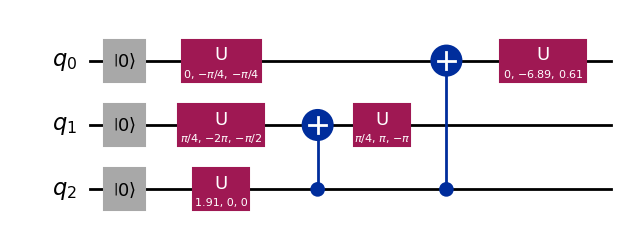

In [1]:
import math
import numpy as np
from qiskit import QuantumCircuit
 
desired_state = [1 / math.sqrt(3), 0, 0, 0, 0, 1 / math.sqrt(3), 0, 1 / math.sqrt(3)]
 
qc = QuantumCircuit(3)
qc.initialize(desired_state, [0, 1, 2])
qc.decompose(reps=8).draw(output="mpl")

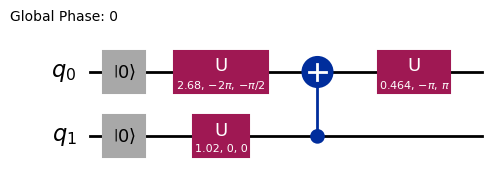

In [2]:
desired_state = [
    1 / math.sqrt(105) * 4,
    1 / math.sqrt(105) * 8,
    1 / math.sqrt(105) * 5,
    1 / math.sqrt(105) * 0,
]
 
qc = QuantumCircuit(2)
qc.initialize(desired_state, [0, 1])
 
qc.decompose(reps=5).draw(output="mpl")

In [3]:
from qiskit.quantum_info import Statevector
from math import pi
 
qc = QuantumCircuit(1)
state1 = Statevector.from_instruction(qc)
qc.ry(pi / 2, 0)  # Phase gate rotates by an angle pi/2
state2 = Statevector.from_instruction(qc)
states = state1, state2

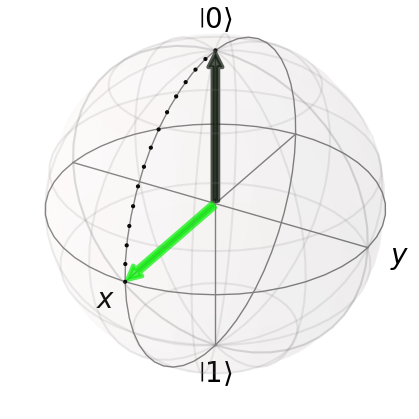

In [4]:
from qiskit.visualization.bloch import Bloch
from qiskit.visualization.state_visualization import _bloch_multivector_data
 
 
def plot_Nstates(states, axis, plot_trace_points=True):
    """This function plots N states to 1 Bloch sphere"""
    bloch_vecs = [_bloch_multivector_data(s)[0] for s in states]
 
    if axis is None:
        bloch_plot = Bloch()
    else:
        bloch_plot = Bloch(axes=axis)
 
    bloch_plot.add_vectors(bloch_vecs)
 
    if len(states) > 1:
 
        def rgba_map(x, num):
            g = (0.95 - 0.05) / (num - 1)
            i = 0.95 - g * num
            y = g * x + i
            return (0.0, y, 0.0, 0.7)
 
        num = len(states)
        bloch_plot.vector_color = [rgba_map(x, num) for x in range(1, num + 1)]
 
    bloch_plot.vector_width = 3
    bloch_plot.vector_style = "simple"
 
    if plot_trace_points:
 
        def trace_points(bloch_vec1, bloch_vec2):
            # bloch_vec = (x,y,z)
            n_points = 15
            thetas = np.arccos([bloch_vec1[2], bloch_vec2[2]])
            phis = np.arctan2(
                [bloch_vec1[1], bloch_vec2[1]], [bloch_vec1[0], bloch_vec2[0]]
            )
            if phis[1] < 0:
                phis[1] = phis[1] + 2 * pi
            angles0 = np.linspace(phis[0], phis[1], n_points)
            angles1 = np.linspace(thetas[0], thetas[1], n_points)
 
            xp = np.cos(angles0) * np.sin(angles1)
            yp = np.sin(angles0) * np.sin(angles1)
            zp = np.cos(angles1)
            pnts = [xp, yp, zp]
            bloch_plot.add_points(pnts)
            bloch_plot.point_color = "k"
            bloch_plot.point_size = [4] * len(bloch_plot.points)
            bloch_plot.point_marker = ["o"]
 
        for i in range(len(bloch_vecs) - 1):
            trace_points(bloch_vecs[i], bloch_vecs[i + 1])
 
    bloch_plot.sphere_alpha = 0.05
    bloch_plot.frame_alpha = 0.15
    bloch_plot.figsize = [4, 4]
 
    bloch_plot.render()
 
 
plot_Nstates(states, axis=None, plot_trace_points=True)